# Install Libraries yang diperlukan

In [1]:
!pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Load Datasetnya

In [2]:
from datasets import load_dataset

# meload dataset
ds = load_dataset("nothingiisreal/Short-Storygen-v2")

# melihat informasi dataset
print(ds)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/282 [00:00<?, ?B/s]

Opus_Storygen-6K-v2.json:   0%|          | 0.00/19.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5668 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'tokens', 'system', 'model', 'id', 'response'],
        num_rows: 5668
    })
})


# Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd

train_df = pd.DataFrame(ds['train'])

# melihat informasi dasar
print("Train Dataset:")
print(train_df.info())
print(train_df.head())

# mengecek apa ada values yang hilang
print("\nMissing values in Train Dataset:")
print(train_df.isnull().sum())

# analisa panjang text baik prompt atau response
train_df['prompt_length'] = train_df['prompt'].apply(len)
train_df['response_length'] = train_df['response'].apply(len)

print("\nPrompt Length Statistics:")
print(train_df['prompt_length'].describe())

print("\nResponse Length Statistics:")
print(train_df['response_length'].describe())

Train Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5668 entries, 0 to 5667
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   prompt    5668 non-null   object
 1   tokens    5668 non-null   int64 
 2   system    5668 non-null   object
 3   model     5668 non-null   object
 4   id        5668 non-null   object
 5   response  5668 non-null   object
dtypes: int64(1), object(5)
memory usage: 265.8+ KB
None
                                              prompt  tokens  \
0  Develop a concise narrative using the text sni...     749   
1  Craft a mini-tale where 'My cat got sick. I to...     839   
2  Build a short story that incorporates: 'I went...     657   
3  Embed this statement in a short narrative: 'In...     781   
4  Make a brief story. Use the lead-in as your st...     691   

                                              system                   model  \
0  You are to play the role of a noble laurette i... 

 # Preprocess the Data

In [4]:
import pandas as pd

# ubah dataset format dataframa panda
train_df = pd.DataFrame(ds['train'])

# hapus kolom yang tidak perlu
train_df = train_df.drop(columns=['tokens', 'system', 'model', 'id'])

# bersihkan text dari hal yang tidak perlukan
def clean_text(text):
    text = text.strip()  # hapus space tak teratur
    text = " ".join(text.split())  # hapus space berlebih
    return text

train_df['prompt'] = train_df['prompt'].apply(clean_text)
train_df['response'] = train_df['response'].apply(clean_text)

# ambil salah satu kata dari respon agar bisa dipakai sebagai judul
def extract_title(response):
    # bagi response menjadi kumpulan kalimat
    sentences = response.split(". ")
    if len(sentences) > 0:
        # pakai kata pertama sebagai judul
        title = sentences[0]
        # hapus tanda baca dan space yang tidak beraturan
        title = title.strip().rstrip(".")
        return title
    else:
        # kalau tidak ada kata-kata dari response yang bisa dijadikan judul maka pilih 10 kata random
        words = response.split()[:10]
        return " ".join(words)

train_df['title'] = train_df['response'].apply(extract_title)

# combinasi judul dan respon didalam 1 format
train_df['text'] = "Title: " + train_df['title'] + "\n\nParagraph 1: " + train_df['response']

# tampilkan dataset yang sudah bersih
print(train_df.head())

                                              prompt  \
0  Develop a concise narrative using the text sni...   
1  Craft a mini-tale where 'My cat got sick. I to...   
2  Build a short story that incorporates: 'I went...   
3  Embed this statement in a short narrative: 'In...   
4  Make a brief story. Use the lead-in as your st...   

                                            response  \
0  The Johnsons' New Beginning It had been a tumu...   
1  "Whiskers of Fate" It was a gloomy Sunday morn...   
2  The Wedding Reunion As I stepped out of the ca...   
3  The air was thick with anticipation and excite...   
4  The Gathering Excitement filled the air as the...   

                                               title  \
0  The Johnsons' New Beginning It had been a tumu...   
1  "Whiskers of Fate" It was a gloomy Sunday morn...   
2  The Wedding Reunion As I stepped out of the ca...   
3  The air was thick with anticipation and excite...   
4  The Gathering Excitement filled the air as 

# Tokenize Datasetnya

In [5]:
from transformers import AutoTokenizer
from datasets import Dataset
import pandas as pd

# ubah dataset format dataframa panda
train_df = pd.DataFrame(ds['train'])

# hapus kolom yang tidak perlu
train_df = train_df.drop(columns=['tokens', 'system', 'model', 'id'])

def clean_text(text):
    text = text.strip()
    text = " ".join(text.split())
    return text

train_df['prompt'] = train_df['prompt'].apply(clean_text)
train_df['response'] = train_df['response'].apply(clean_text)

def extract_title(response):

    sentences = response.split(". ")
    if len(sentences) > 0:
        title = sentences[0]
        title = title.strip().rstrip(".")
        return title
    else:
        words = response.split()[:10]
        return " ".join(words)

train_df['title'] = train_df['response'].apply(extract_title)

train_df['text'] = "Title: " + train_df['title'] + "\n\nParagraph 1: " + train_df['response']

print(train_df.head())

# ubah ke bentuk dataset huggingface
train_dataset = Dataset.from_pandas(train_df)

# splitdataset jadi train dan valid
train_dataset, val_dataset = train_dataset.train_test_split(test_size=0.2).values()

# persiapan Tokenize dataset
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")

# Set padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Use EOS token as padding token

# Tokenize dataset
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Set labels untuk causal language modeling
tokenized_train = tokenized_train.map(lambda x: {"labels": x["input_ids"]})
tokenized_val = tokenized_val.map(lambda x: {"labels": x["input_ids"]})

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

                                              prompt  \
0  Develop a concise narrative using the text sni...   
1  Craft a mini-tale where 'My cat got sick. I to...   
2  Build a short story that incorporates: 'I went...   
3  Embed this statement in a short narrative: 'In...   
4  Make a brief story. Use the lead-in as your st...   

                                            response  \
0  The Johnsons' New Beginning It had been a tumu...   
1  "Whiskers of Fate" It was a gloomy Sunday morn...   
2  The Wedding Reunion As I stepped out of the ca...   
3  The air was thick with anticipation and excite...   
4  The Gathering Excitement filled the air as the...   

                                               title  \
0  The Johnsons' New Beginning It had been a tumu...   
1  "Whiskers of Fate" It was a gloomy Sunday morn...   
2  The Wedding Reunion As I stepped out of the ca...   
3  The air was thick with anticipation and excite...   
4  The Gathering Excitement filled the air as 

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/4534 [00:00<?, ? examples/s]

Map:   0%|          | 0/1134 [00:00<?, ? examples/s]

Map:   0%|          | 0/4534 [00:00<?, ? examples/s]

Map:   0%|          | 0/1134 [00:00<?, ? examples/s]

Pakai Model Yang sudah dilatih skip tahapan lainnya

# Load DistilGPT-2 sebagai model

In [6]:
from transformers import AutoModelForCausalLM
import torch

# Load DistilGPT-2 model
model = AutoModelForCausalLM.from_pretrained("distilgpt2")

# Masukan model ke GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on {device}")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on cuda


# cek perplexity sebelum training

In [7]:
import torch
from torch.nn.functional import cross_entropy

def calculate_perplexity(model, dataset):
    model.eval()  # Set model ke evaluation mode
    total_loss = 0
    total_tokens = 0

    for batch in dataset:
        inputs = torch.tensor(batch['input_ids']).to(device)
        labels = torch.tensor(batch['labels']).to(device)

        with torch.no_grad():
            outputs = model(inputs, labels=labels)
            loss = outputs.loss
            total_loss += loss.item() * inputs.size(0)  # kalikan dengan batch size
            total_tokens += inputs.size(0)

    # hitung rata-rata loss and perplexity
    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return perplexity

# hitung perplexity awal
initial_perplexity = calculate_perplexity(model, tokenized_val)
print(f"Initial Perplexity: {initial_perplexity}")

Initial Perplexity: 44.3282585144043


#Training Modelnya

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,2.995300,2.773455
2,2.818900,2.694311
3,2.732300,2.644205
4,2.666700,2.609895
5,2.613300,2.577689
6,2.568400,2.558303
7,2.529800,2.539282
8,2.495400,2.525810
9,2.465000,2.511493
10,2.436100,2.502212


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


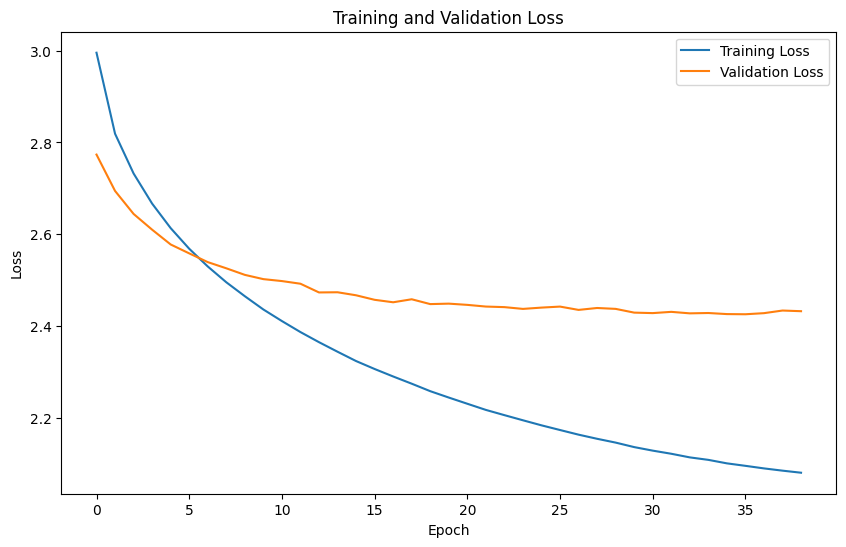

In [8]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling, EarlyStoppingCallback

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=50,
    weight_decay=0.01,
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    fp16=True,
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

# pakai DataCollatorForLanguageModeling untuk causal language modeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

# inisiasi Trainer dengan early stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Train model
trainer.train()

# visualisikan hasil training
import matplotlib.pyplot as plt

train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
eval_losses = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Save model dan tokenizer

In [9]:
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")


('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.json',
 './saved_model/merges.txt',
 './saved_model/added_tokens.json',
 './saved_model/tokenizer.json')

# cek perplexity sesudah training

In [10]:
final_perplexity = calculate_perplexity(model, tokenized_val)
print(f"Final Perplexity: {final_perplexity}")

Final Perplexity: 62.064388275146484


# Pakai Model Yang sudah dilatih skip tahapan lainnya

In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer
model = AutoModelForCausalLM.from_pretrained("./saved_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_model")

# Mulai Mengenerate short story menggunakan prompt

In [23]:
import torch
import textwrap
from IPython.display import display, HTML

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained("./saved_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_model")

model.to(device)

def generate_story(prompt, max_length=600):
    structured_prompt = f"Title: {prompt}\n\nParagraph 1:"
    inputs = tokenizer(structured_prompt, return_tensors="pt").to(device)
    outputs = model.generate(
        inputs['input_ids'],
        max_length=max_length,
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        top_k=50,
        top_p=0.95,
        temperature=0.7,
        do_sample=True,
        attention_mask=inputs['attention_mask'],
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        early_stopping=True
    )
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return format_story(generated_text)

def format_story(text):
    parts = text.split("\n\n")
    title = parts[0].replace("Title: ", "").strip()
    paragraphs = [p.replace("Paragraph ", "").strip() for p in parts[1:]]
    formatted_story = f"Title: {title}\n\n"
    for i, paragraph in enumerate(paragraphs):
        if paragraph.startswith(f"{i+1}:"):
            paragraph = paragraph.split(":", 1)[1].strip()
        wrapped_paragraph = textwrap.fill(paragraph, width=80)
        formatted_story += f"Paragraph {i+1}:\n{wrapped_paragraph}\n\n"
    return formatted_story

def ensure_ending(text):
    if not text.strip().endswith(('.', '!', '?')):
        last_period = text.rfind('.')
        last_exclamation = text.rfind('!')
        last_question = text.rfind('?')
        last_punctuation = max(last_period, last_exclamation, last_question)
        if last_punctuation != -1:
            text = text[:last_punctuation + 1]
    return text

prompt = "different family"
generated_story = generate_story(prompt)
generated_story = ensure_ending(generated_story)
display(HTML(f"<pre style='white-space: pre-wrap;'>{generated_story}</pre>"))